In [1]:
# Seeding for reproducability
import random 
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf 
tf.random.set_seed(0)


In [2]:
# importing the dependancies 
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing import image
from sklearn.metrics import  confusion_matrix
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

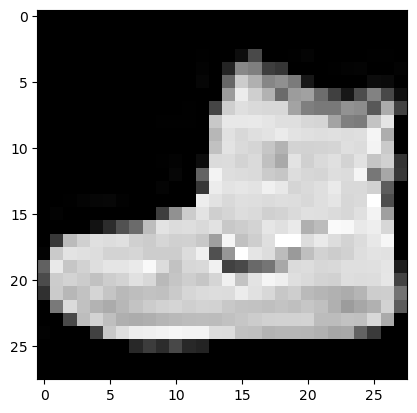

In [3]:
# load and prepare the fashion-mnist data
fashion_mnist = datasets.fashion_mnist
(train_images, train_labels),(test_images, test_labels)= fashion_mnist.load_data()
# Data processing 
plt.imshow(train_images[0], cmap='grey')
plt.show()

In [4]:
# Normalize the pixel value to be between 0 and 1 
train_images, test_images = train_images / 255.0, test_images / 255.0

In [5]:
# Reshape images 
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [6]:
# CNN

In [8]:
# Define the Neural Network
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3), activation = 'relu'))

#  Add dense layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# Model Compilation
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])


In [9]:
# Training the model
history = model.fit(train_images, train_labels, epochs = 5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.7540 - loss: 0.6841 - val_accuracy: 0.8695 - val_loss: 0.3718
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.8777 - loss: 0.3444 - val_accuracy: 0.8826 - val_loss: 0.3262
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8945 - loss: 0.2878 - val_accuracy: 0.8904 - val_loss: 0.3075
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9061 - loss: 0.2536 - val_accuracy: 0.8932 - val_loss: 0.2973
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9160 - loss: 0.2267 - val_accuracy: 0.8943 - val_loss: 0.2987


313/313 - 2s - 6ms/step - accuracy: 0.8943 - loss: 0.2987
Test accuracy is  0.8942999839782715


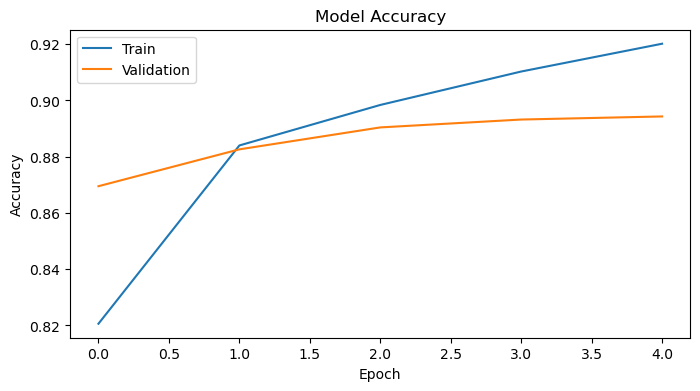

In [10]:
# Evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('Test accuracy is ', test_acc)

# plot training and validation accuracy values 
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label = 'Train')
plt.plot(history.history['val_accuracy'], label = 'Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

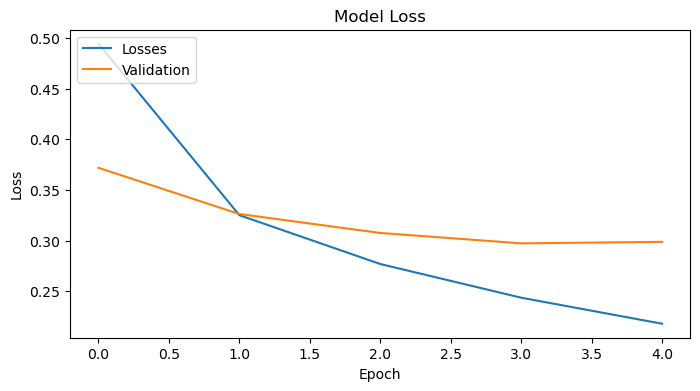

In [11]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label = 'Losses')
plt.plot(history.history['val_loss'], label = 'Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


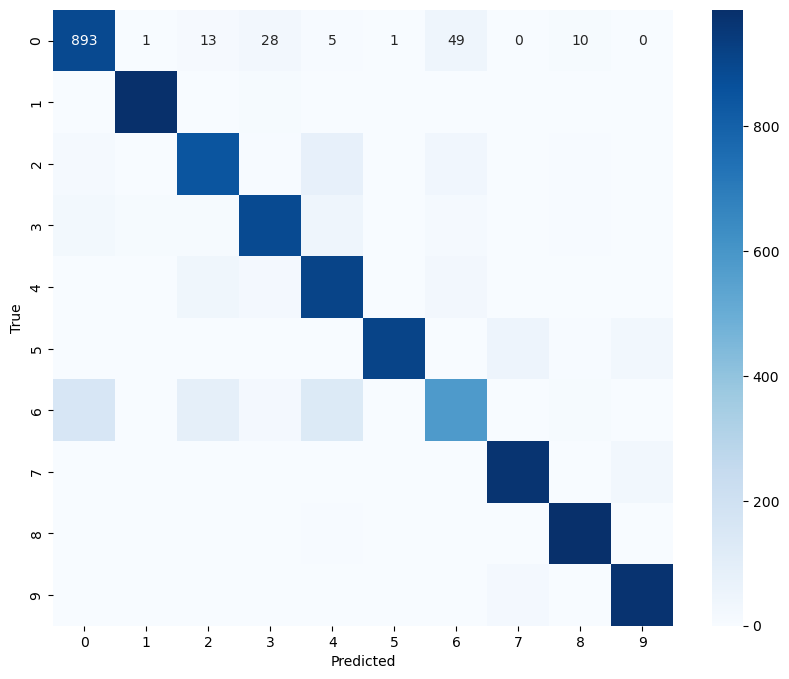

In [18]:
# Confusion matrix 
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1) # Get the class with the highest probability
confusion_mtx = confusion_matrix(test_labels, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
def preprocess_image(img_path):
    img = image.load_img(img_path,target_size=(28,28), color_mode='grayscale')
    img_array= image.img_to_array(img)
    img_array = img_array/255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_image(model, img_array):
    prediction = model.predict(img_array)
    predicted_label = np.argmax(prediction, axis=1)
    return predicted_label[0]

# load smaple images
# Assuming test_images is already defined and contains image data
for i in range(len(test_images)):
  img_array = np.expand_dims(test_images[i], axis=0)
  predicted_label = predict_image(model, img_array)
  predicted_class_name = class_names[predicted_label]
  print(f"Image {i}: Predicted class - {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Image 0: Predicted class - Ankle Boot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Image 1: Predicted class - Pullover
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image 2: Predicted class - Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image 3: Predicted class - Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image 4: Predicted class - Shirt
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Image 5: Predicted class - Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Image 6: Predicted class - Coat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Image 7: Predicted class - Shirt
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image 8: Predicted class - Sandal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image 9: Predicted class - Sneaker
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Image 10: Predicted class - Coat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Image 11: Predicted class - Sandal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Image 12: Predicted class - Sneaker
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Image 13: Predict